In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/RtmpTG9OwR/remotes4b261f878bbc/grosed-bagel-4f8972c/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.5.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



In [2]:
packageVersion("bagelR")

[1] ‘1.5.0’

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

In [5]:
prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

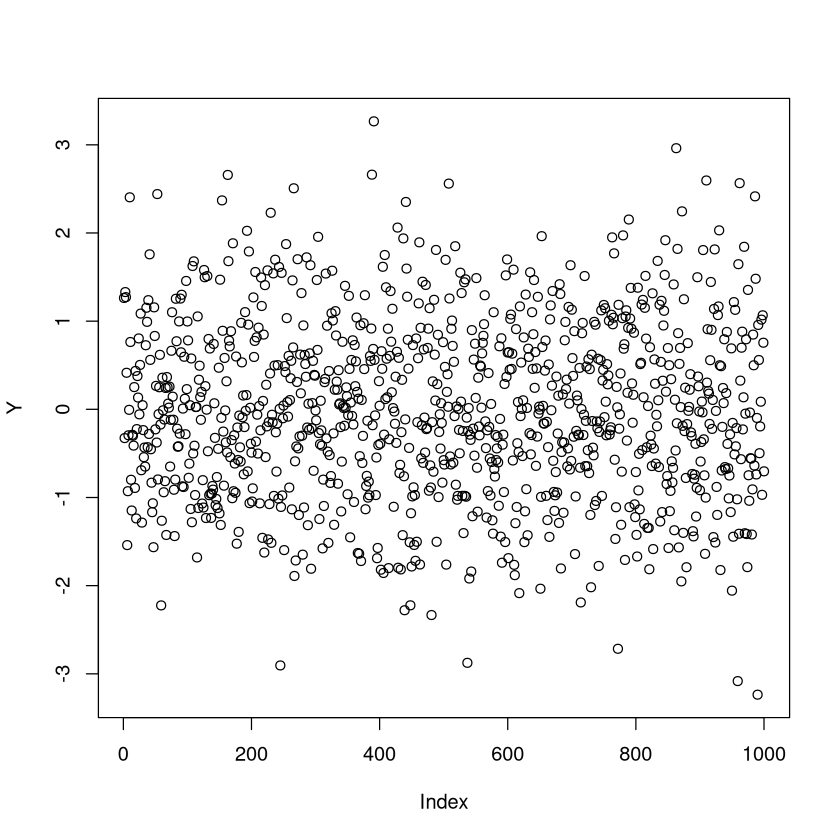

In [7]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

In [8]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

In [ ]:
results <- bagel_kv_exact(Y,feature_vector,prior,transform,p0,p,noise_sd,max_particles,threshold)

In [16]:
sequential_bagel_kv_exact <- function(feature_vector,prior,transform,p0,p,sigma,max_particles)
{
   bagel_object <- new("bagel_kv_exact_type",feature_vector=feature_vector,
				             prior=prior,
			                     transform=transform,
			                     p0=p0,
			                     p=p,
			                     sigma=sigma,
			                     max_particles=max_particles,
			                     bagel_object=new(bagelR_kv_exact,p0,p,sigma,max_particles))
  return(bagel_object)

}

In [28]:
# get_weights
setGeneric("get_weights",function(object) standardGeneric("get_weights"))
setMethod("get_weights","bagel_kv_exact_type",
          function(object)
	  {
	    return(object@bagel_object$get_weights())
	  })

[1] "get_weights"

In [29]:
# set_weights
setGeneric("set_weights",function(object,weights) standardGeneric("set_weights"))
setMethod("set_weights","bagel_kv_exact_type",
          function(object,weights)
	  {
         object@bagel_object$set_weights(weights)     
	  })

[1] "set_weights"

In [17]:
results <- sequential_bagel_kv_exact(feature_vector,prior,transform,p0,p,noise_sd,max_particles)

In [18]:
update(results,Y[1])

[1] 0.9

In [24]:
results@bagel_object$get_weights()

[1] 0.9

In [21]:
class(results)

[1] "bagel_kv_exact_type"
attr(,"package")
[1] "bagelR"

In [27]:
get_weights(results)

[1] 0.9

In [31]:
results@bagel_object$set_weights(c(0.8))

ERROR: Error in results@bagel_object$set_weights(c(0.8)): unused argument (c(0.8))


In [30]:
set_weights(results,c(0.8))

ERROR: Error in object@bagel_object$set_weights(weights): unused argument (weights)
